In [1]:
params <- list(
    i_norm_counts_tab="results/ASVs_counts_normalized.tsv",
    i_distances_matrix="results/ASVs_euclidean_distance.tsv",
    i_taxa_table="results/ASVs_taxa.tsv",
    all_meta="data/initial/all_meta.csv"
)

In [2]:
library(phyloseq)
library(ggplot2)
library(vegan)
library(gt)
library(dplyr)
library(tibble)
library(dendextend)
source("workflow/steps/03_alpha_beta/scripts/ploting/dendrogram.R")

Loading required package: permute


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'dendextend':
  method     from 
  rev.hclust vegan


---------------------
Welcome to dendextend version 1.19.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:permute’:



In [3]:
norm_counts_tab <- read.csv(params$i_norm_counts_tab,sep = "\t", row.names='X')
samples_info <- read.csv(params$all_meta, row.names='Run')[colnames(norm_counts_tab), ]
euc_dist_all <- as.dist(as.matrix(read.csv(
    params$i_distances_matrix, 
    sep='\t', 
    header=T,
    row.names=1
)))
taxa_table <- as.matrix(read.csv(params$i_taxa_table, sep = "\t", row.names=1))


counts_phy <- otu_table(norm_counts_tab, taxa_are_rows = T)
samples_info_phy <- sample_data(samples_info)
taxa_table_phy <- tax_table(taxa_table)

phy <- phyloseq(counts_phy, samples_info_phy, taxa_table_phy)

meta <- data.frame(sample_data(phy))
predictors <- c('depr_or_control', 'batch', 'd_sex', 'd_age_hc')
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")

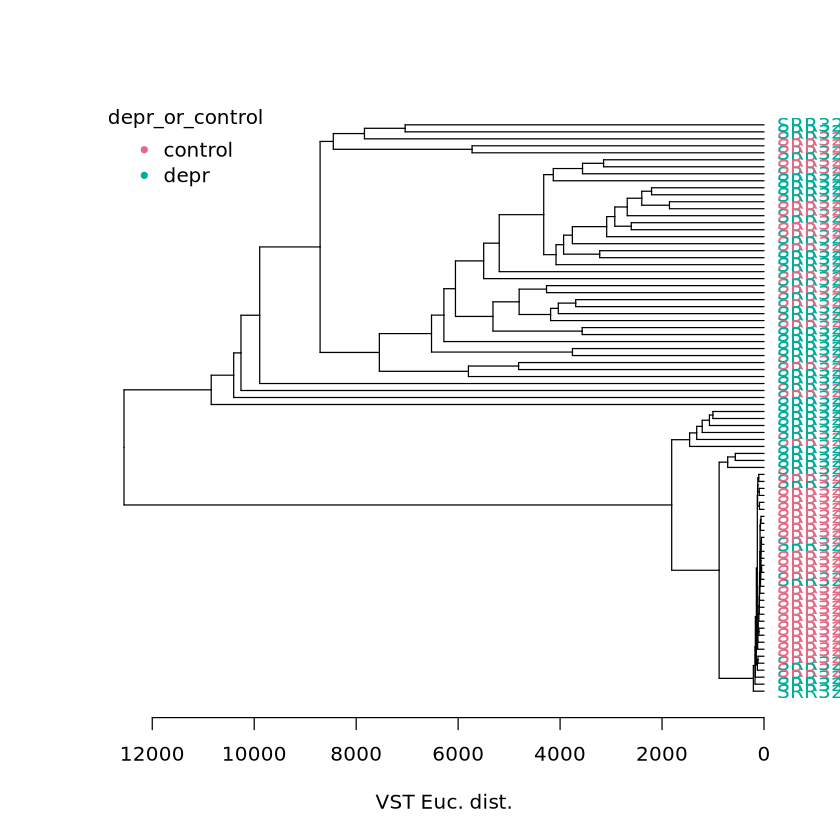

In [4]:
plot_dendrogram(euc_dist_all, phy, depr_or_control)

# Beta dispersion

Plod ordination plot by ASV

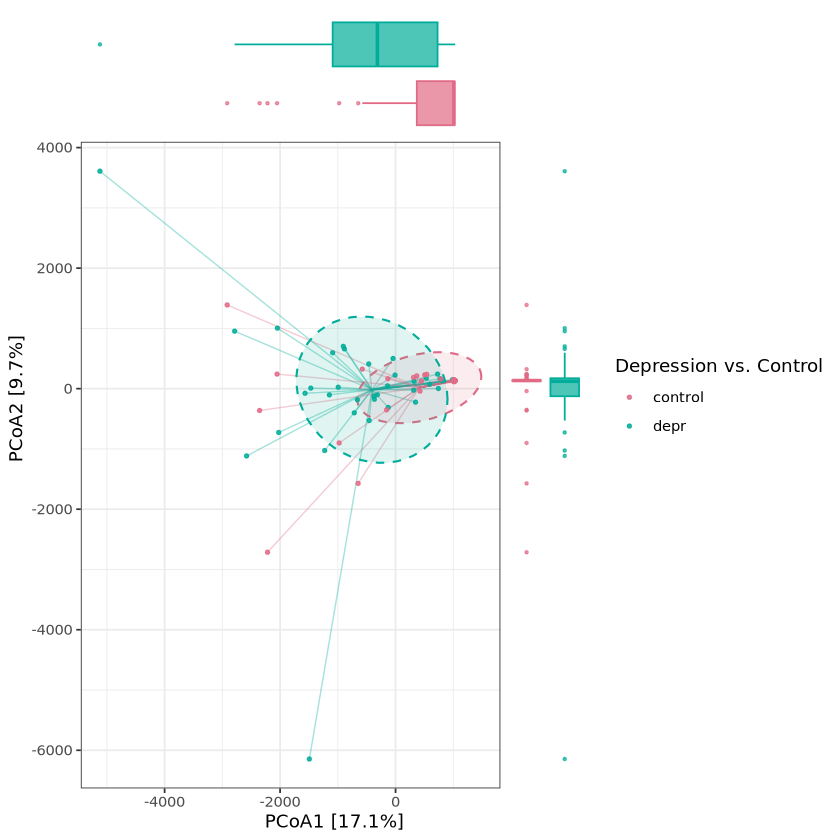

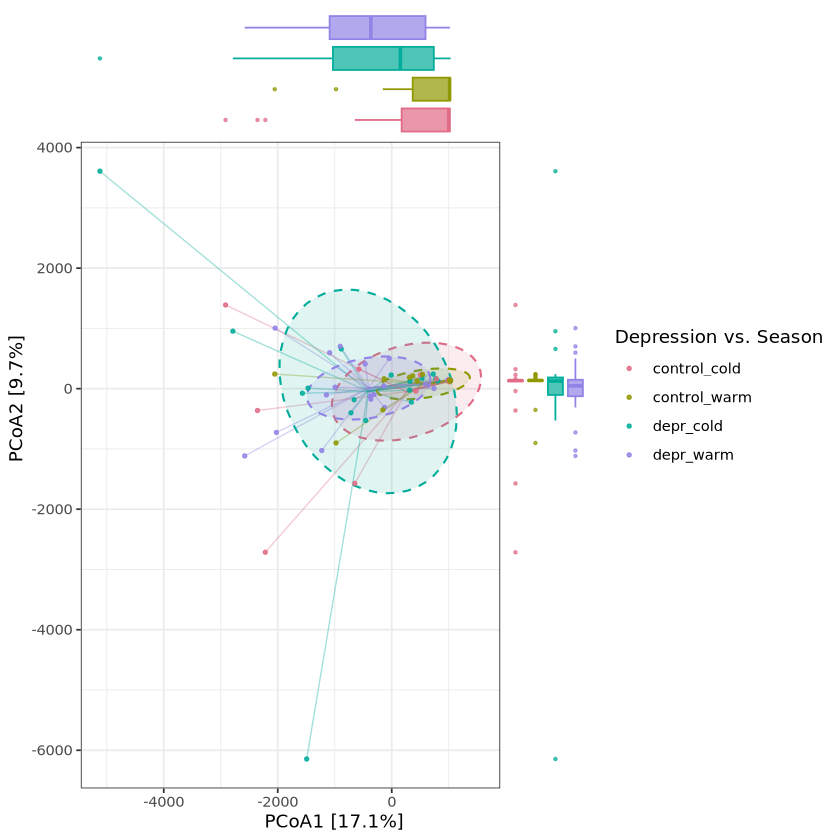

In [7]:
source("workflow/steps/03_alpha_beta/scripts/ploting/pcoa.R")
ord_res <- plot_pcoa(phy, euc_dist_all, depr_or_control, legend_title="Depression vs. Control")
pcoa <- ord_res$pcoa
plot_pcoa(phy, euc_dist_all, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

## Analyze extreme samples from ordination

In [8]:
scores <- as.data.frame(pcoa$points)
d2 <- mahalanobis(
    scores,
    colMeans(scores),
    cov(scores)
)
outliers <- which(
    d2 > qchisq(0.975, df = 2)
)

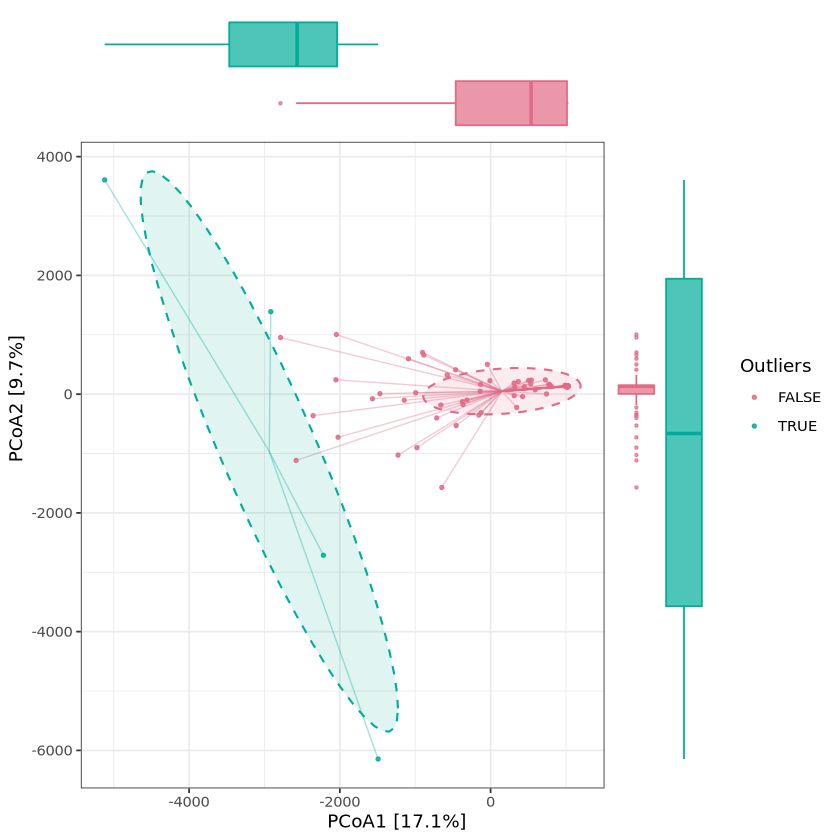

In [9]:
plot_pcoa(phy, euc_dist_all, rownames(sample_data(phy)) %in% names(outliers), legend_title="Outliers")

Firstly, check metadata for extreme samples

In [10]:
names(outliers)
sample_data(phy)[
    names(outliers),
    c('d_sex', 'd_age_hc', 'bd_education3_vs', 'depr_or_control', 'season', 'match_group')
]

[1] "SRR32393342" "SRR32393438" "SRR32393319" "SRR32393681"

,d_sex,d_age_hc,bd_education3_vs,depr_or_control,season,match_group
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
SRR32393342,female,69.26215,Secondary,depr,cold,MG1031355
SRR32393438,male,50.39014,Higher,depr,cold,MG1160966
SRR32393319,female,49.06776,Secondary,control,cold,MG1072255
SRR32393681,female,65.32512,Higher,control,cold,MG1154806


Ok... nothing special in these metadata. Lets check sequencing metrics

In [11]:
reads_loss <- read.csv('results/reads_loss_summary.tsv', sep="\t")
reads_loss$group <- factor(ifelse(rownames(reads_loss) %in% names(outliers), 'extreme', 'regular'), levels = c('regular', 'extreme'))

In [12]:
library(tidyverse)

reads_loss_plot <- reads_loss |>
    rownames_to_column("sample") |>
    transmute(
        sample,
        group,
        Filtered = filtered / input,
        Merged = merged / input,
        Nochim = nochim / input
    ) |>
    pivot_longer(
        -c(sample, group),
        names_to = "stage",
        values_to = "retention"
    )

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ lubridate 1.9.5     ✔ stringr   1.6.0
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()      masks stats::filter()
✖ purrr::flatten()     masks rlang::flatten()
✖ purrr::flatten_chr() masks rlang::flatten_chr()
✖ purrr::flatten_dbl() masks rlang::flatten_dbl()
✖ purrr::flatten_int() masks rlang::flatten_int()
✖ purrr::flatten_lgl() masks rlang::flatten_lgl()
✖ purrr::flatten_raw() masks rlang::flatten_raw()
✖ purrr::invoke()      masks rlang::invoke()
✖ dplyr::lag()         masks stats::lag()
✖ purrr::splice()      masks rlang::splice()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


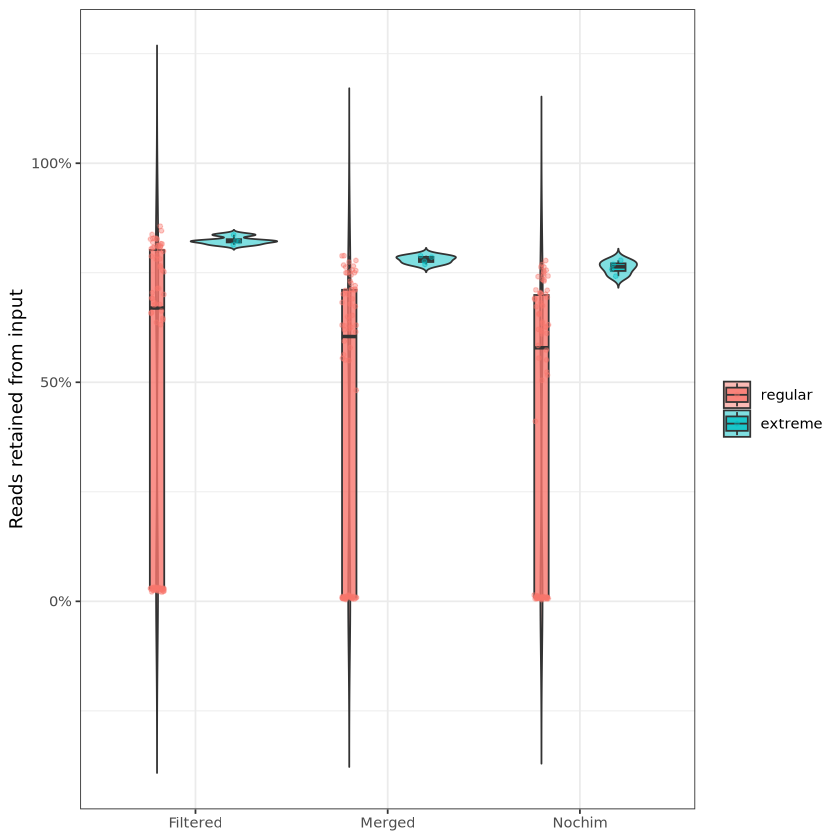

In [13]:
ggplot(
    reads_loss_plot,
    aes(
        x = stage,
        y = retention,
        fill = group
    )
) +
    geom_violin(
        position = position_dodge(width = 0.8),
        trim = FALSE,
        alpha = 0.5
    ) +
    geom_boxplot(
        width = 0.15,
        position = position_dodge(width = 0.8),
        outlier.shape = NA,
        alpha = 0.8
    ) +
    geom_jitter(
        aes(color = group),
        position = position_jitterdodge(
            jitter.width = 0.15,
            dodge.width = 0.8
        ),
        alpha = 0.4,
        size = 1
    ) +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1)
    ) +
    labs(
        x = NULL,
        y = "Reads retained from input",
        fill = NULL,
        color = NULL
    ) +
    theme_bw()

Trend of reads loss kinda the same for regular reads and extreme

Check number of taxa 

In [14]:
ntaxa(phy)

extreme_phy <- prune_samples(names(outliers), phy)
extreme_phy <- prune_taxa(taxa_sums(extreme_phy) > 0, extreme_phy)
ntaxa(extreme_phy)

[1] 3246

[1] 729

In [15]:
taxa_per_sample <- function(phy) as.data.frame(rowSums(t(otu_table(phy)) > 0))
'All samples'
summary(taxa_per_sample(phy))
'Extreme samples'
summary(taxa_per_sample(extreme_phy))

[1] "All samples"

 rowSums(t(otu_table(phy)) > 0)
 Min.   : 15.0                 
 1st Qu.: 42.5                 
 Median :217.5                 
 Mean   :197.0                 
 3rd Qu.:313.0                 
 Max.   :520.0                 

[1] "Extreme samples"

 rowSums(t(otu_table(phy)) > 0)
 Min.   :165.0                 
 1st Qu.:242.2                 
 Median :290.5                 
 Mean   :279.0                 
 3rd Qu.:327.2                 
 Max.   :370.0                 

Looks like average amount of taxa a little bigger for extreme samples 

Ok. Lest try plot ordination without outliers

In [16]:
phy_1 <- subset_samples(phy, !(rownames(sample_data(phy)) %in% names(outliers)))
nsamples(phy_1)

[1] 78

## Chao1, Shannon, Simpson

In [17]:
library(rlang)
plot_rarecurve <- function(ps, color_condition) {
    group_condition <- rlang::enquo(color_condition)
    group <- rlang::eval_tidy(
        group_condition,
        data=sample_data(ps)
    )
    group <- factor(group)
    group_levels <- levels(group)
    group_colors <- setNames(hcl.colors(length(group_levels), palette = "Dark 3"), group_levels)
    otu_matrix <- t(as.data.frame(otu_table(ps)))
    rarecurve(otu_matrix, step=100, lwd=2, ylab="ASVs", label=FALSE, col=group_colors[group])
    legend("bottomright", legend=levels(group), col=group_colors, lwd=2, bty="n")
    abline(v=(min(rowSums(otu_matrix))))
}

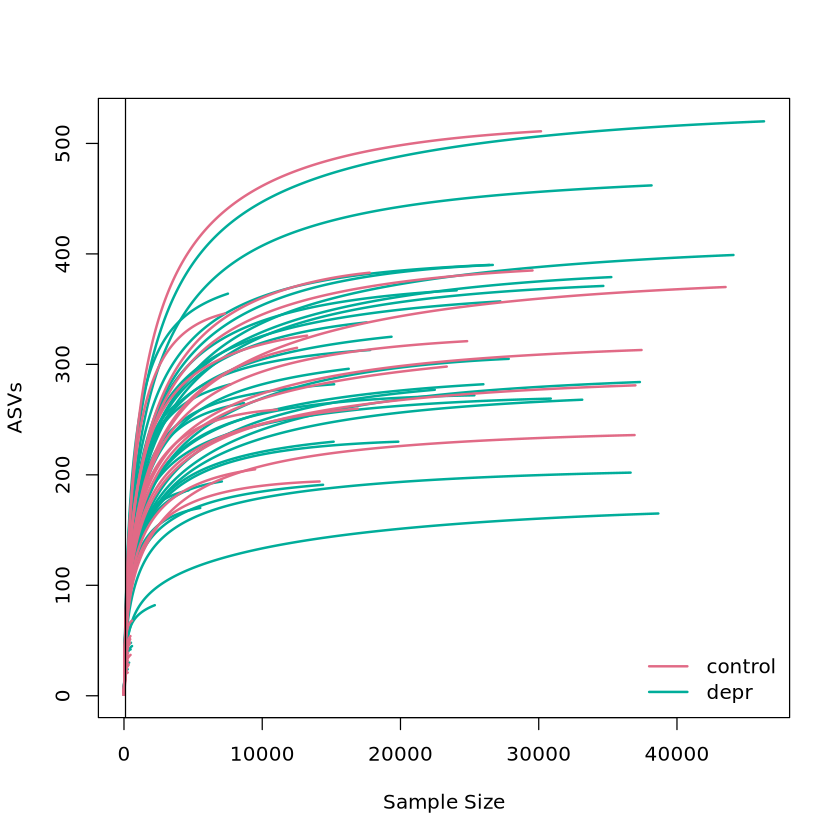

In [18]:
plot_rarecurve(phy, depr_or_control)

[1] "Extreme samples"

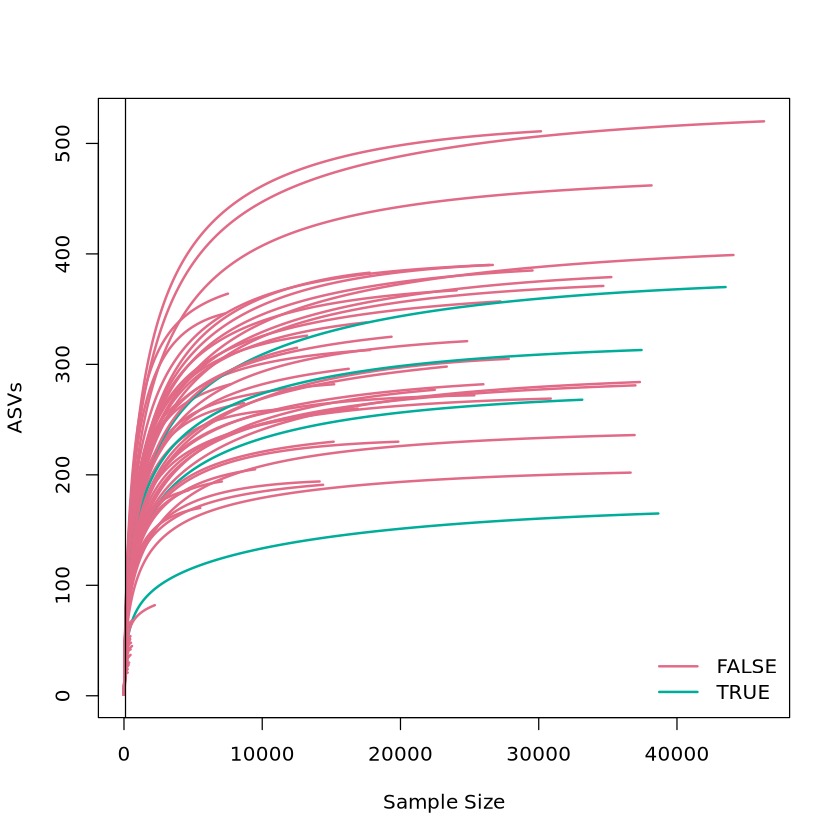

In [19]:
'Extreme samples'
plot_rarecurve(phy, rownames(sample_data(phy)) %in% names(outliers))

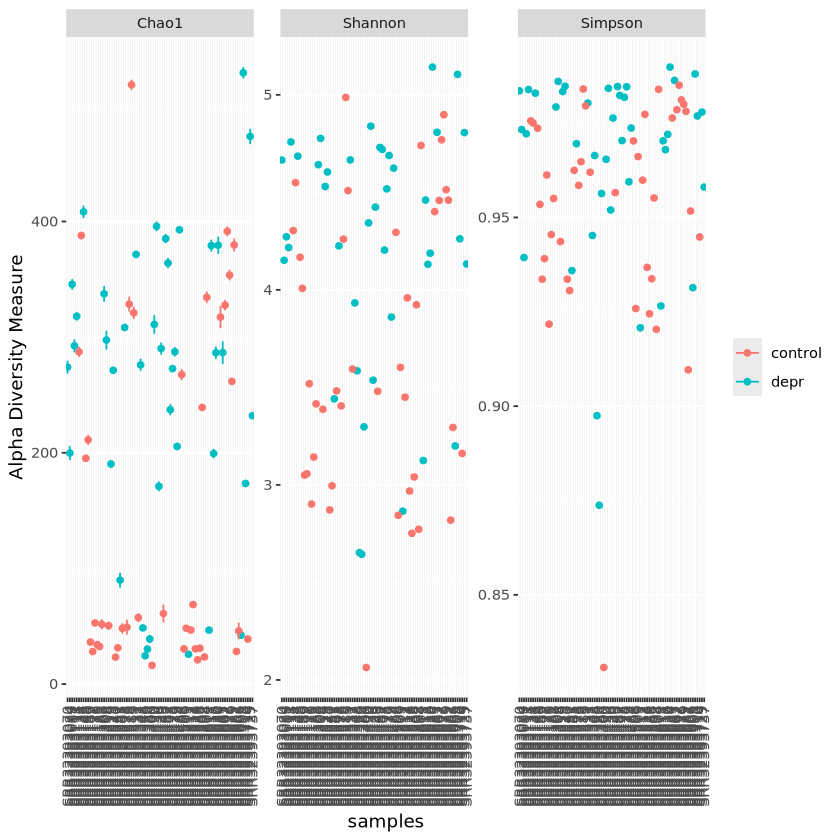

In [92]:
# Alpha diversity plot Depression
plot_richness(phy, color="depr_or_control", measures = c("Chao1", "Shannon", "Simpson")) +
    theme(
        legend.title = element_blank(),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    )